# Regime-Adaptive Portfolio: S&P 500 + Gold

This notebook builds two strategies and compares them:
1. **Baseline (No Regimes):** Static allocation to S&P 500 and Gold, rebalanced monthly.
2. **Regime Strategy (HMM):** Hidden Markov Model classifies market regimes on S&P 500 returns; allocations switch between 80/20 and 20/80 based on detected regime.

You'll get clean charts, performance metrics, and a side-by-side comparison.

**Requirements**: `pandas`, `numpy`, `matplotlib`, `yfinance`, `hmmlearn`, `scikit-learn` (optional), `scipy` (optional).

In [1]:
# !pip install pandas numpy matplotlib yfinance hmmlearn scikit-learn scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from datetime import datetime

plt.rcParams['figure.figsize'] = (11, 5)
pd.options.display.float_format = '{:.6f}'.format

print('Libraries imported.')

Libraries imported.


## 1) Configuration
- Choose tickers
- Choose date range
- Choose baseline (static) weights and HMM regime weights

In [2]:
CFG = {
    'tickers': {'stocks': '^GSPC', 'gold': 'GC=F'},
    'start': '2005-01-01',
    'end': datetime.today().strftime('%Y-%m-%d'),
    # Baseline static weights (no regimes), e.g., 60/40 stocks/gold
    'baseline_weights': {'stocks': 0.60, 'gold': 0.40},
    # Regime weights
    'bull_weights': {'stocks': 0.80, 'gold': 0.20},
    'bear_weights': {'stocks': 0.20, 'gold': 0.80},
    # Rolling window for features
    'lookback': 30,
}
CFG

{'tickers': {'stocks': '^GSPC', 'gold': 'GC=F'},
 'start': '2005-01-01',
 'end': '2026-06-12',
 'baseline_weights': {'stocks': 0.6, 'gold': 0.4},
 'bull_weights': {'stocks': 0.8, 'gold': 0.2},
 'bear_weights': {'stocks': 0.2, 'gold': 0.8},
 'lookback': 30}

## 2) Data Download and Return Calculation
- We use Adjusted Close prices
- Compute daily returns for both assets
- (Optional) You can resample to monthly if you prefer lower noise

In [3]:
import pandas as pd
import yfinance as yf

tickers = [CFG['tickers']['stocks'], CFG['tickers']['gold']]

# With auto_adjust=True (default), prices are already adjusted; select "Close"
df = yf.download(tickers, start=CFG['start'], end=CFG['end'], auto_adjust=True)

# Handle single- vs multi-ticker shapes
if isinstance(df.columns, pd.MultiIndex):
    prices = df['Close'].copy()
else:
    # Single-ticker case
    prices = df[['Close']].copy()

# Ensure we have exactly two columns in the expected order (stocks, gold)
# If Yahoo returns columns out of order, this enforces the map explicitly.
col_map = {}
for col in prices.columns:
    if col.upper() in ['^GSPC', 'GSPC']:
        col_map[col] = 'STOCKS'
    elif col.upper() in ['GC=F', 'GLD']:
        col_map[col] = 'GOLD'

prices = prices.rename(columns=col_map)

# If symbols didn't match (e.g., different tickers), fallback to positional rename
if 'STOCKS' not in prices.columns or 'GOLD' not in prices.columns:
    prices = prices.copy()
    prices.columns = ['STOCKS','GOLD']  # assumes tickers list order [stocks, gold]

# Align, drop missing days where either is NaN (different trading calendars)
raw = prices.dropna(how='any')

# Daily returns
rets = raw.pct_change().dropna()
rets.head()


[*********************100%***********************]  2 of 2 completed


Ticker,GOLD,STOCKS
Date,,
2005-01-04,-0.000467,-0.011671
2005-01-05,-0.004434,-0.003628
2005-01-06,-0.013127,0.003506
2005-01-07,-0.004988,-0.001431
2005-01-10,0.000477,0.003423


## 3) Helper Functions
- Performance metrics (CAGR, Sharpe, Volatility, Max Drawdown)
- Simple monthly rebalancing logic
- Plot utilities

In [4]:
def perf_metrics(returns, freq=252):
    cum = (1 + returns).prod()
    n_years = len(returns) / freq
    cagr = cum ** (1 / n_years) - 1 if n_years > 0 else np.nan
    vol = returns.std() * np.sqrt(freq)
    sharpe = returns.mean() / returns.std() * np.sqrt(freq) if returns.std() != 0 else np.nan
    # Max drawdown
    curve = (1 + returns).cumprod()
    peak = curve.cummax()
    dd = (curve / peak - 1).min()
    return {'CAGR': cagr, 'Volatility': vol, 'Sharpe': sharpe, 'MaxDD': dd}

def monthly_rebalanced_portfolio(returns_df, weights_dict):
    weights = pd.Series(weights_dict)
    # Ensure alignment
    returns_df = returns_df[['STOCKS','GOLD']].copy()
    # Monthly rebalancing: compute monthly weights and apply daily returns within month
    months = returns_df.index.to_period('M')
    port_ret = []
    prev_month = None
    for idx, row in returns_df.iterrows():
        cur_month = idx.to_period('M')
        if prev_month is None or cur_month != prev_month:
            w = weights.copy()  # rebalance at month start
        # daily portfolio return
        r = (row['STOCKS'] * w['stocks']) + (row['GOLD'] * w['gold'])
        port_ret.append(r)
        prev_month = cur_month
    port_ret = pd.Series(port_ret, index=returns_df.index, name='PORT')
    return port_ret

def plot_cum(curves_dict, title='Cumulative Returns'):
    plt.figure()
    for label, series in curves_dict.items():
        plt.plot((1+series).cumprod(), label=label)
    plt.title(title)
    plt.legend()
    plt.show()

print('Helpers ready.')

Helpers ready.


## 4) Baseline Strategy (No Regimes)
Static weights (e.g., 60% Stocks / 40% Gold), **monthly rebalanced**.

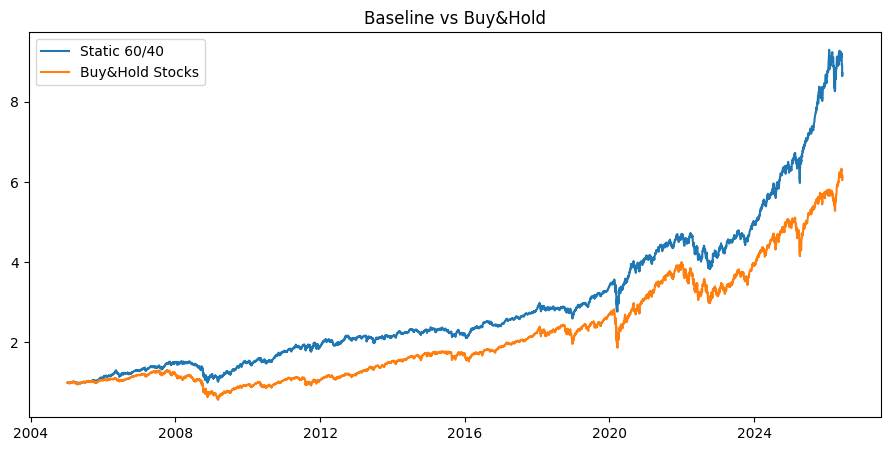

,Static 60/40,Buy&Hold Stocks
CAGR,0.106668,0.088749
Volatility,0.138069,0.190697
Sharpe,0.803376,0.541518
MaxDD,-0.352862,-0.567754


In [5]:
baseline_ret = monthly_rebalanced_portfolio(rets, CFG['baseline_weights'])
bh_ret = rets['STOCKS']  # Buy & Hold stocks as a reference

plot_cum({'Static 60/40': baseline_ret, 'Buy&Hold Stocks': bh_ret}, title='Baseline vs Buy&Hold')

pd.DataFrame({
    'Static 60/40': perf_metrics(baseline_ret),
    'Buy&Hold Stocks': perf_metrics(bh_ret)
})

## 5) Regime Classification with HMM
- Fit a 2-state Gaussian HMM on **stock returns**
- Label state with **higher mean return** as **Bull**; the other as **Bear**
- Switch weights accordingly: Bull → 80/20, Bear → 20/80

You can also incorporate features like rolling volatility; for simplicity we start with returns only.

In [ ]:
# -------------------------
# Step 5 (REPLACEMENT): Robust HMM + Walk-forward monthly HMM (no lookahead)
# -------------------------
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")  # hide convergence warnings for clarity

# --- Helper: robust HMM fit (scaling + multi-restart) ---
def robust_hmm_fit(X_raw, n_components=2, n_restart=8, clip_pct=0.10, random_state=0, cov_type='diag', n_iter=1000, tol=1e-4):
    """
    Fit GaussianHMM robustly on X_raw (N x d).
    - clips extremes to +/-clip_pct
    - scales features (StandardScaler)
    - tries multiple random initializations, returns best model & scaler & scaled X
    """
    X_raw = np.asarray(X_raw)
    # clip (winsorize) extremes to improve numerical stability
    X_clipped = np.clip(X_raw, -clip_pct, clip_pct)
    scaler = StandardScaler()
    X = scaler.fit_transform(X_clipped)

    best_model = None
    best_score = -np.inf
    for seed in range(n_restart):
        try:
            model = GaussianHMM(n_components=n_components,
                                covariance_type=cov_type,
                                n_iter=n_iter,
                                tol=tol,
                                random_state=seed)
            model.fit(X)
            score = model.score(X)
            if score > best_score:
                best_score = score
                best_model = model
        except Exception:
            # ignore failed initializations
            continue

    if best_model is None:
        raise RuntimeError("HMM fit failed for all restarts. Try reducing clip_pct or n_components.")
    return best_model, scaler, X, X_clipped

# --- Whole-sample (robust) HMM regime (for quick inspection) ---
X_raw = rets[['STOCKS']].dropna().values  # shape (N,1)
model_ws, scaler_ws, Xs, Xs_clipped = robust_hmm_fit(X_raw, n_components=2, n_restart=8)
states_ws = model_ws.predict(Xs)
# Map states to 'Bull'/'Bear' by comparing original-returns means
state_means_ws = {s: X_raw[states_ws==s].mean() for s in np.unique(states_ws)}
bull_state_ws = max(state_means_ws, key=state_means_ws.get)
regime_series_wf_ws = pd.Series(np.where(states_ws==bull_state_ws, 'Bull', 'Bear'),
                             index=rets[['STOCKS']].dropna().index, name='Regime_WS')

print("Whole-sample HMM state counts:")
print(regime_series_wf_ws.value_counts())

# --- Walk-forward monthly HMM: fit only on history at each month-start (NO LOOKAHEAD) ---
def walkforward_regime_series_wf(rets, feature_col='STOCKS', lookback_min_days=60, n_components=2, n_restart=6, clip_pct=0.10):
    """
    Walk-forward monthly regime labeling.
    - For each month, fit HMM on historical returns up to day before first trading day of month.
    - Assign month's regime = state on last training day (Bull if state mean is higher).
    - Returns: pd.Series indexed same as rets with 'Bull'/'Bear' labels (daily, forward-filled).
    """
    dates = rets.index
    months = sorted(set(dates.to_period('M')))
    regime_daily = pd.Series(index=rets.index, dtype="object")

    for month_period in months:
        # the first trading day of this month
        month_first_day = rets[rets.index.to_period('M') == month_period].index.min()
        # training end = index position before month_first_day
        train_end_pos = rets.index.get_loc(month_first_day) - 1
        if train_end_pos < 0:
            # insufficient past data -> default label (e.g., Bull)
            regime_label = 'Bull'
            regime_daily.loc[rets.index[rets.index.to_period('M') == month_period]] = regime_label
            continue

        train_end_date = rets.index[train_end_pos]
        X_train_raw = rets.loc[:train_end_date, [feature_col]].dropna().values
        if len(X_train_raw) < lookback_min_days:
            # not enough history -> fallback to default
            regime_label = 'Bull'
            regime_daily.loc[rets.index[rets.index.to_period('M') == month_period]] = regime_label
            continue

        # fit robust HMM on historical data only
        model, scaler, X_scaled, X_clipped = robust_hmm_fit(X_train_raw,
                                                            n_components=n_components,
                                                            n_restart=n_restart,
                                                            clip_pct=clip_pct)
        states = model.predict(X_scaled)
        state_means = {s: X_train_raw[states==s].mean() for s in np.unique(states)}
        bull_state = max(state_means, key=state_means.get)
        last_state = states[-1]
        regime_label = 'Bull' if last_state == bull_state else 'Bear'

        # assign regime for every trading day in this month
        regime_daily.loc[rets.index[rets.index.to_period('M') == month_period]] = regime_label

    # fill any edge NaNs
    regime_daily = regime_daily.ffill().bfill()
    return regime_daily

# Run walk-forward routine (this may take a few seconds)
regime_series_wf_wf = walkforward_regime_series_wf(rets, feature_col='STOCKS',
                                             lookback_min_days=60,
                                             n_components=2, n_restart=6, clip_pct=0.10)

print("\nWalk-forward HMM state counts:")
print(regime_series_wf_wf.value_counts())

# --- Notes for downstream use ---
# Use `regime_series_wf_wf` in your regime-based portfolio functions (it has NO lookahead).
# If you want to compare, you can also inspect regime_series_wf_ws (whole-sample), but don't use it for live/backtesting.
#
# Example: replace old regime_series_wf with:
#   regime_series_wf = regime_series_wf_wf
#
# Then call your regime_portfolio/regime_rebalanced_with_costs functions as before.



Whole-sample HMM state counts:
Regime_WS
Bull    3998
Bear    1386
Name: count, dtype: int64

Walk-forward HMM state counts:
Bull    3817
Bear    1567
Name: count, dtype: int64


## 6) Regime-Adaptive Portfolio Construction
- Bull: 80% Stocks / 20% Gold
- Bear: 20% Stocks / 80% Gold
- Rebalance at the **start of each month** using the most recent regime label

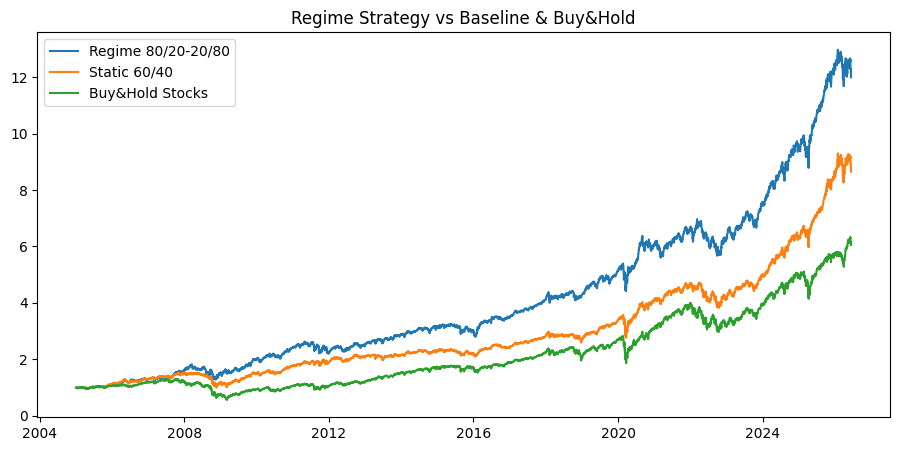

,Regime 80/20-20/80,Static 60/40,Buy&Hold Stocks
CAGR,0.123978,0.106668,0.088749
Volatility,0.135962,0.138069,0.190697
Sharpe,0.927818,0.803376,0.541518
MaxDD,-0.296537,-0.352862,-0.567754


In [11]:
def regime_weights_at_time(ts_idx, regime_label, bull_w, bear_w):
    return bull_w if regime_label=='Bull' else bear_w

def regime_portfolio(returns_df, regime_series_wf, bull_w, bear_w):
    returns_df = returns_df[['STOCKS','GOLD']].copy()
    # Align indices
    regime_series_wf = regime_series_wf.reindex(returns_df.index).ffill().bfill()

    port_ret = []
    prev_month = None
    current_w = None
    for idx, row in returns_df.iterrows():
        cur_month = idx.to_period('M')
        if prev_month is None or cur_month != prev_month:
            # set weights based on current regime at month start
            rlabel = regime_series_wf.loc[idx]
            current_w = regime_weights_at_time(idx, rlabel, bull_w, bear_w)
        r = row['STOCKS'] * current_w['stocks'] + row['GOLD'] * current_w['gold']
        port_ret.append(r)
        prev_month = cur_month
    return pd.Series(port_ret, index=returns_df.index, name='RegimePORT')

reg_port = regime_portfolio(
    rets,
    regime_series_wf,
    CFG['bull_weights'],
    CFG['bear_weights']
)

plot_cum({'Regime 80/20-20/80': reg_port, 'Static 60/40': baseline_ret, 'Buy&Hold Stocks': bh_ret},
         title='Regime Strategy vs Baseline & Buy&Hold')

pd.DataFrame({
    'Regime 80/20-20/80': perf_metrics(reg_port),
    'Static 60/40': perf_metrics(baseline_ret),
    'Buy&Hold Stocks': perf_metrics(bh_ret)
})






## 7) Drawdowns & Extras (Optional)
- Drawdown plots help visualize risk
- You can also add a 3-regime model (Bull/Neutral/Bear) later

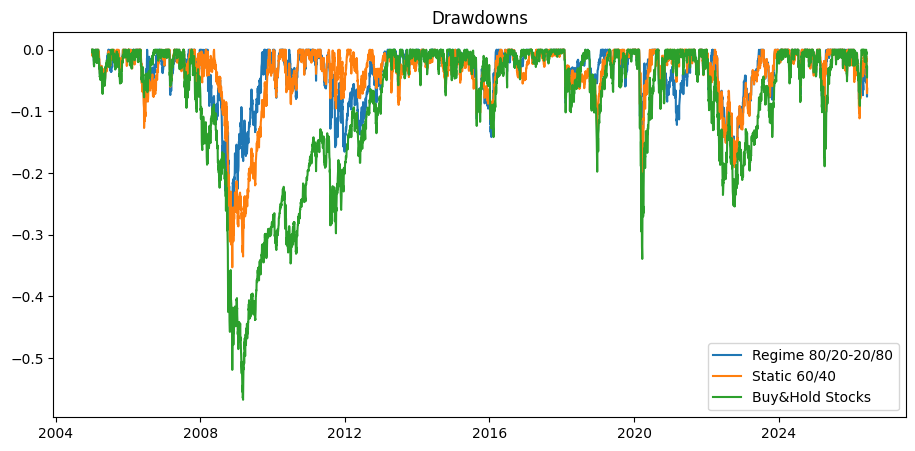

In [12]:
def drawdown_series(ret):
    curve = (1 + ret).cumprod()
    peak = curve.cummax()
    dd = curve/peak - 1
    return dd

dd_reg = drawdown_series(reg_port)
dd_baseline = drawdown_series(baseline_ret)
dd_bh = drawdown_series(bh_ret)

plt.figure()
plt.plot(dd_reg, label='Regime 80/20-20/80')
plt.plot(dd_baseline, label='Static 60/40')
plt.plot(dd_bh, label='Buy&Hold Stocks')
plt.title('Drawdowns')
plt.legend(); plt.show()



## 8) Notes & Future Work
- Add **rolling volatility** as an additional feature to the HMM (2D features)
- Try **3 regimes** (Bull / Neutral / Bear) with 90/10, 60/40, 20/80 weights
- Add **transaction costs & slippage** (e.g., 2–5 bps per trade)
- Do **walk-forward** estimation: fit HMM only on past data up to each month
- Compare **Gold vs Bonds** as the defensive asset

## 9) Supervised Regime Forecasting (Pseudo-Labeling)

In this section, we use the HMM-inferred regimes as pseudo-labels and train supervised models to predict the **next day's regime**.

Pipeline:
1. Generate HMM regime labels.
2. Engineer momentum, volatility, trend, and gold-related features.
3. Shift labels forward by one day to predict the future regime.
4. Train Random Forest and Logistic Regression classifiers.
5. Compare classification performance.
6. Backtest portfolios driven by predicted regimes.


In [13]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split

feat = prices.copy()

feat['spx_ret_1d'] = prices['STOCKS'].pct_change()
feat['spx_ret_5d'] = prices['STOCKS'].pct_change(5)
feat['spx_ret_20d'] = prices['STOCKS'].pct_change(20)

feat['gold_ret_1d'] = prices['GOLD'].pct_change()
feat['gold_ret_5d'] = prices['GOLD'].pct_change(5)

feat['vol_5d'] = feat['spx_ret_1d'].rolling(5).std()
feat['vol_20d'] = feat['spx_ret_1d'].rolling(20).std()

feat['ma20_ratio'] = prices['STOCKS'] / prices['STOCKS'].rolling(20).mean()
feat['ma50_ratio'] = prices['STOCKS'] / prices['STOCKS'].rolling(50).mean()

# Convert Bull/Bear to 1/0
label_map = {'Bear':0, 'Bull':1}
feat['regime'] = regime_series_wf.map(label_map)

# Predict next regime
feat['target'] = feat['regime'].shift(-1)

feat = feat.dropna()

feature_cols = [
    'spx_ret_1d','spx_ret_5d','spx_ret_20d',
    'gold_ret_1d','gold_ret_5d',
    'vol_5d','vol_20d',
    'ma20_ratio','ma50_ratio'
]

X = feat[feature_cols]
y = feat['target']

split = int(len(feat)*0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
lr_pred = lr.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Logistic Regression F1:", f1_score(y_test, lr_pred))

print("\nRandom Forest Report")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.8918128654970761
Random Forest F1: 0.922970159611381

Logistic Regression Accuracy: 0.7134502923976608
Logistic Regression F1: 0.8268551236749117

Random Forest Report
              precision    recall  f1-score   support

         0.0       0.87      0.77      0.82       324
         1.0       0.90      0.95      0.92       702

    accuracy                           0.89      1026
   macro avg       0.89      0.86      0.87      1026
weighted avg       0.89      0.89      0.89      1026



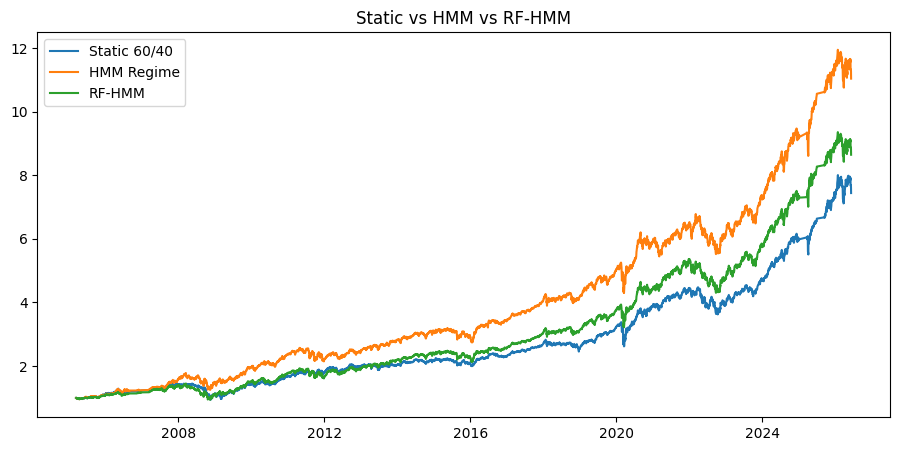

['spx_ret_1d', 'spx_ret_5d', 'spx_ret_20d', 'gold_ret_1d', 'gold_ret_5d', 'vol_5d', 'vol_20d', 'ma20_ratio', 'ma50_ratio']


In [15]:

# Portfolio driven by predicted regimes

pred_series = pd.Series(
    rf.predict(X),
    index=X.index
).map({0:'Bear',1:'Bull'})

pred_port = regime_portfolio(
    rets.loc[pred_series.index],
    pred_series,
    CFG['bull_weights'],
    CFG['bear_weights']
)

comparison = pd.DataFrame({
    'Static 60/40': perf_metrics(baseline_ret),
    'HMM Regime': perf_metrics(reg_port),
    'RF-HMM': perf_metrics(pred_port)
})

comparison

plot_cum({
    'Static 60/40': baseline_ret.loc[pred_port.index],
    'HMM Regime': reg_port.loc[pred_port.index],
    'RF-HMM': pred_port
}, title='Static vs HMM vs RF-HMM')
print(X.columns.tolist())